<a href="https://colab.research.google.com/github/lnajjemba/dswb-open-science-capacity-wg/blob/main/Introduction_to_Bias_in_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Bias Identification and Mitigation in AI


### Objectives
1. **Understand Algorithms & Inequality:** Go over the taxonomy of bias.
2. **Fairness Metrics:** Understand the definitions and clinical contexts of metrics like Demographic Parity and Equalized Odds.
3. **Auditing:** Use Python (`fairlearn`) to assess a clinical dataset.
4. **Explainable AI:** Use SHAP (SHapley Additive exPlanations) to uncover *why* models act fairly or unfairly.
5. **Bias Mitigation:** Apply post-processing techniques.

## 1. The Taxonomy of Bias

Algorithmic bias refers to systematic and repeatable errors in AI models that produce unfair outcomes. In healthcare, these biases primarily originate from:

1. **Data-driven Biases:**
   *   **Representation (Sampling) Bias:** Occurs when training data lacks diversity and doesn't reflect the target patient population.
   *   **Historical Bias:** Arises when past structural inequalities and discriminatory policies are embedded in the data (e.g., predicting health needs based on previous healthcare costs, which systematically underestimates the needs of marginalized groups who historically spent less due to lack of access).
   *   **Measurement Error & Label Choice Bias:** Using flawed proxy variables like "hospital admission" as a proxy for actual disease severity.

2. **Algorithmic Biases:**
   *   **Aggregation Bias:** Ignoring distinct subgroup patterns and forcing a single "one-size-fits-all" model.
   *   **Overfitting to Majority Populations:** Optimizing for the largest demographic group at the expense of minorities.

### African Context: Mapping Protected Attributes
In the US-centric dataset we will use today, bias is predominantly analyzed through `race` (Caucasian vs. African American). While technically sufficient for this Python demonstration, bias and protected attributes in African clinical research manifest differently, for example:
*   **Geographic Divides:** Severe disparities in urban vs. rural healthcare access.
*   **Socioeconomic Status (SES):** Insurance coverage types (e.g., NHIF vs. out-of-pocket) or reliance on underfunded public vs. private facilities.
*   **Language Barriers:** Intake disparities where symptom descriptions in low-resource local languages are poorly translated or summarized into clinical notes.
*   **Infrastructure Proxies:** Distance to the nearest referral hospital. Machine learning models will quickly learn to use this geographic data as a hidden proxy for socioeconomic vulnerability.

### Intersectionality
Individuals hold multiple social identities. Analyzing "Gender" and "Urban/Rural" separately might reveal no overall bias, but examining their intersection (e.g., "Rural Women") may expose severe, compounded disparities.

## 2. Environment Setup

In [ ]:
!pip install -q fairlearn scikit-learn pandas numpy matplotlib seaborn ipywidgets shap

In [ ]:
# Import Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import ipywidgets as widgets
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix

from fairlearn.datasets import fetch_diabetes_hospital
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference
from fairlearn.metrics import false_positive_rate, false_negative_rate, true_positive_rate, true_negative_rate
from fairlearn.postprocessing import ThresholdOptimizer

sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

## 3. Dataset Loading & EDA

We will use the **Diabetes 130-US Hospitals dataset**. It contains clinical care data over a 10-year period (1999-2008) at 130 US hospitals.

**The Clinical Task**: Predict whether a patient with diabetes was readmitted to the hospital within 30 days (`readmit_30_days`). This is critical because early readmission indicates a failure in the initial treatment or discharge plan.

**The Fairness Task**: Ensure our predictive model operates equitably across different demographic groups, focusing on `race`, `gender`, and their intersections.

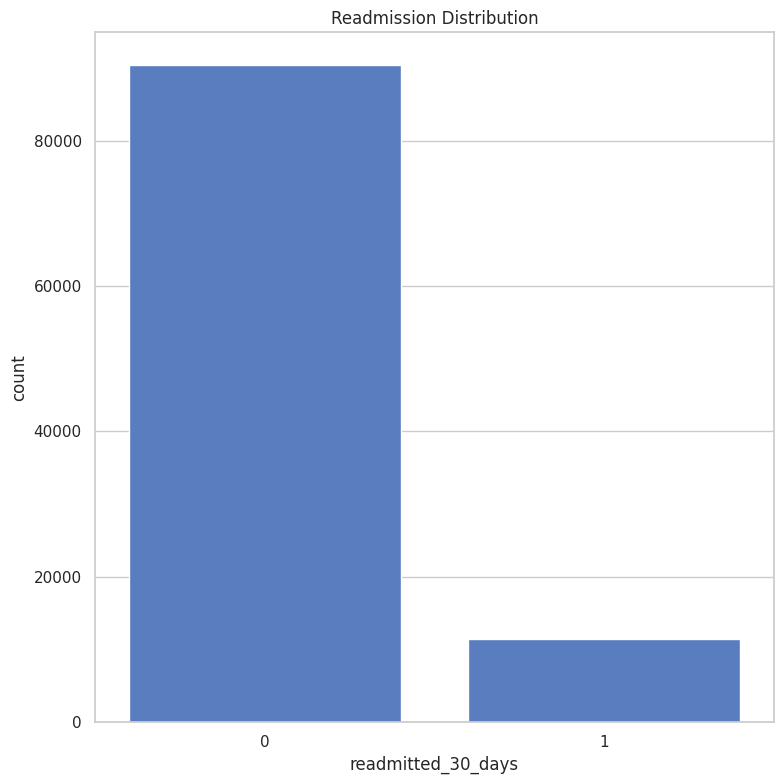

In [ ]:
# Fetch the Dataset
data = fetch_diabetes_hospital(as_frame=True)
X_raw = data.data
y_raw = data.target

# Add target back temporarily for EDA
df_eda = X_raw.copy()
df_eda['readmitted_30_days'] = y_raw

# Visualizing Readmission Distribution
fig, axes = plt.subplots(1, 1, figsize=(8, 8))
sns.countplot(data=df_eda, x='readmitted_30_days', ax=axes)
axes.set_title('Readmission Distribution')

plt.tight_layout()
plt.show()

In [ ]:
# Select features for our pipeline
features_to_use = [
    'race', 'gender', 'age', 'admission_source_id',
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'had_outpatient_days', 'had_emergency',
    'had_inpatient_days', 'max_glu_serum', 'A1Cresult'
]

X = X_raw[features_to_use]

# Drop 'Unknown' race for this specific tutorial validation
valid_idx = X['race'].isin(['Caucasian', 'AfricanAmerican', 'Hispanic', 'Other', 'Asian'])
X = X[valid_idx]
y = y_raw[valid_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 4. Model Selection & Training a Baseline Model

Notice in our EDA that the dataset is highly imbalanced (only ~11% are readmitted). If we use a standard algorithm without adjusting for this, the model will achieve a high accuracy by simply predicting "No Readmission" for everyone.

To ensure our model actually learns, we select a `RandomForestClassifier` and pass `class_weight='balanced'`.

In [ ]:
# Define feature types
categorical_features = [col for col in X.columns if X[col].dtype != np.int64]
numeric_features = [col for col in X.columns if col not in categorical_features]

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Baseline Model with Class Weighting
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, max_depth=10, class_weight='balanced', n_jobs=-1))
])

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['race', 'gender', 'age',
                                                   'admission_source_id',
                                                   'had_outpatient_days',
                                                   'had_emergency',
                                                   'had_inpatient_days',
                                                   'max_glu_serum',
                                                   'A1Cresult'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_jobs=-1, random_state=42))])

In [ ]:
y_pred_baseline = baseline_model.predict(X_test)
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_baseline).ravel()

print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred_baseline):.3f}")
print(f"Baseline Sensitivity: {recall_score(y_test, y_pred_baseline):.3f}")
print(f"Baseline Specificity: {tn / (tn + fp):.3f}")
print(f"Baseline ROC AUC:  {roc_auc_score(y_test, y_prob_baseline):.3f}")

Baseline Accuracy: 0.672
Baseline Sensitivity: 0.476
Baseline Specificity: 0.697
Baseline ROC AUC:  0.619


> **Note**:

> *Sensistivity, also known as true positive rate (TPR) or recall, measures the proportion of actual positive cases that a model correctly identifies. It answers the question: "Of all the individuals who have the condition, how many did the model correctly identify as having the condition?"*

> *Specificity, also known as true negative rate (TNR), measures the proportion of actual negative cases that are correctly identified as negative. It answers the question: "Of all the individuals who do not have the condition, how many did the model correctly identify as healthy?"*

## 5. Bias Identification and Fairness Metrics (Auditing)

**What Metrics are Relevant?**
*   **Demographic Parity**: Requires the overall proportion of positive predictions to be the same across all groups. Useful in resource allocation.
*   **Equalized Odds**: Requires the model's accuracy (True Positive Rate and False Positive Rate) to be identical across groups. For predictive diagnostic tools like hospital readmission, we prioritize Equalized Odds because a False Negative means depriving a high-risk patient of care. We want error rates to be equitable regardless of demographics.

In [ ]:
metrics = {
    'false_positive_rate': false_positive_rate,
    'true_positive_rate': true_positive_rate,
}

X_test_evaluation = X_test.copy()
X_test_evaluation['race_gender'] = X_test['race'].astype(str) + " - " + X_test['gender'].astype(str)

def evaluate_fairness(protected_attribute):
    print(f"\n--- Auditing Fairness across: {protected_attribute} ---")
    sensitive_features = X_test_evaluation[protected_attribute]

    metric_frame = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_pred_baseline, sensitive_features=sensitive_features)

    metric_frame.by_group[['false_positive_rate', 'true_positive_rate']].plot(
        kind='bar', figsize=(12, 6), colormap='Set2'
    )
    plt.title(f'Metrics by {protected_attribute} (Baseline Model)')
    plt.ylabel('Rate')
    plt.xticks(rotation=45, ha="right")
    plt.legend(['False Positive Rate', 'True Positive Rate'])
    plt.show()

    print("\nRaw Metrics by Group:")
    display(metric_frame.by_group)

    print("\nSummary Fairness Metrics:")
    dp_diff = demographic_parity_difference(y_true=y_test, y_pred=y_pred_baseline, sensitive_features=sensitive_features)
    eo_diff = equalized_odds_difference(y_true=y_test, y_pred=y_pred_baseline, sensitive_features=sensitive_features)

    print(f"Demographic Parity Difference (Disparity in selection rate): {dp_diff:.4f}")
    print(f"Equalized Odds Difference (Max disparity in FPR/TPR):     {eo_diff:.4f}")

# Enable interactive widget rendering for Colab
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass

_ = widgets.interact(evaluate_fairness, protected_attribute=widgets.Dropdown(options=['race', 'gender', 'race_gender'], value='race'))

interactive(children=(Dropdown(description='protected_attribute', options=('race', 'gender', 'race_gender'), v…

> **Observation:**

> *Notice how error rates differ across groups. Furthermore, the `race_gender` intersectional variable often reveals specific sub-populations (e.g., Asian Females vs. African American Males) that face disproportionate error rates that were hidden when analyzing race or gender alone.*

> **Note**:

> *Selection rate is a fairness metric representing the proportion of samples from a specific group that are predicted as positive (e.g., approved for a loan) by a model. It is used to detect bias by comparing these rates across different demographic subgroups, ensuring the model doesn't unfairly favor or disfavor a particular group.*

> *The core difference between Selection Rate and True Positive Rate (TPR) lies in what they measure: Selection Rate focuses on the proportion of instances predicted as positive regardless of whether those prediction are correct, while the True Positive Rate focuses on how well the model identifies actual positive instances*

## 6. Trustworthy AI: Explainability with SHAP

Identifying that bias exists is only half the battle. For researchers focused on clinical applications, understanding *why* the model makes biased decisions is a core pillar of Trustworthy AI.

We will use **SHAP (SHapley Additive exPlanations)** to unpack the "black box" Random Forest model. By analyzing SHAP impact summary plots, we can detect if our model is heavily relying on a **proxy variable**.
For example, if `inpatient_days` holds massive predictive weight, and we know local marginalized populations cannot afford extended inpatient stays, the model is leveraging a structural inequality proxy as a clinical indicator!


--- SHAP Summary Plot (Features driving Readmission Predictions) ---


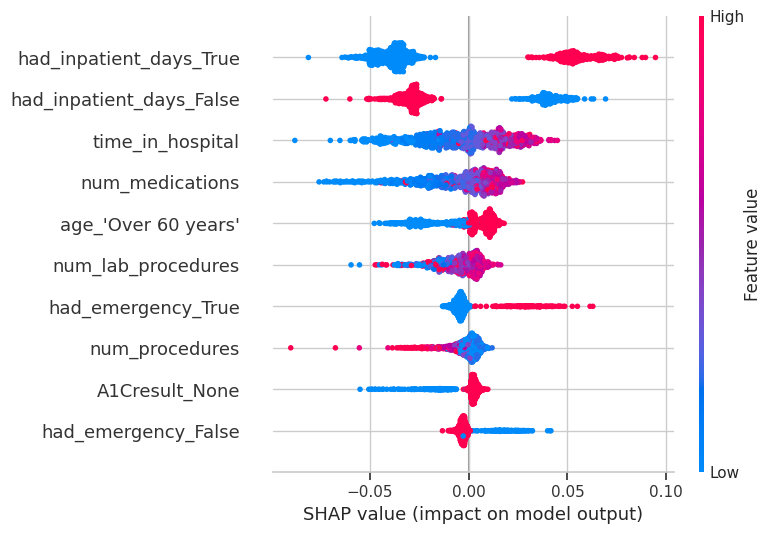

In [ ]:
# Extract preprocessor and model mathematically
preprocessor_fitted = baseline_model.named_steps['preprocessor']
classifier_fitted = baseline_model.named_steps['classifier']

# Transform tests to evaluate feature importance
X_test_transformed = preprocessor_fitted.transform(X_test)

# Reconstruct feature names from pipelines
num_names = numeric_features
cat_names = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([num_names, cat_names])

# Instantiate a TreeExplainer for Random Forest
explainer = shap.TreeExplainer(classifier_fitted)

# SHAP scales poorly, so we sample 500 patients from our test set
X_test_sample = shap.utils.sample(X_test_transformed, 1000)
shap_values = explainer.shap_values(X_test_sample)

# For Random Forest, shap_values is a list for [Class 0, Class 1]. We plot Class 1 (Readmission Risk)
print("\n--- SHAP Summary Plot (Features driving Readmission Predictions) ---")
shap.summary_plot(shap_values[:,:,1], X_test_sample, feature_names=all_feature_names, max_display=10)

## 7. Bias Mitigation (Post-processing)

We will use a **Post-processing** technique called `ThresholdOptimizer` to find group-specific clinical thresholds to strictly enforce Equalized Odds.

Interact with the widget below to optimize for different demographic features and observe how mitigating bias along one axis visually impacts FNR/FPR.

In [ ]:
# 1. Initialize Validation set for Tuning
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

unmitigated_estimator = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, max_depth=10, class_weight='balanced', n_jobs=-1))
])
unmitigated_estimator.fit(X_train_sub, y_train_sub)

X_val_evaluation = X_val.copy()
X_val_evaluation['race_gender'] = X_val['race'].astype(str) + " - " + X_val['gender'].astype(str)

def mitigate_and_evaluate(protected_attribute):
    sf_val = X_val_evaluation[protected_attribute]
    sf_test = X_test_evaluation[protected_attribute]

    postprocess_est = ThresholdOptimizer(
        estimator=unmitigated_estimator,
        constraints="equalized_odds",
        predict_method="predict_proba"
    )
    postprocess_est.fit(X_val, y_val, sensitive_features=sf_val)
    y_pred_mitigated = postprocess_est.predict(X_test, sensitive_features=sf_test)

    mf_baseline = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_pred_baseline, sensitive_features=sf_test)
    mf_mitigated = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_pred_mitigated, sensitive_features=sf_test)

    baseline_tn, baseline_fp, baseline_fn, baseline_tp = confusion_matrix(y_test, y_pred_baseline).ravel()
    baseline_specificity = baseline_tn / (baseline_tn + baseline_fp)

    mitigated_tn, mitigated_fp, mitigated_fn, mitigated_tp = confusion_matrix(y_test, y_pred_mitigated).ravel()
    mitigated_specificity = mitigated_tn / (mitigated_tn + mitigated_fp)

    print(f"Baseline Accuracy:    {accuracy_score(y_test, y_pred_baseline):.3f}   |   Mitigated Sensitivity:   {accuracy_score(y_test, y_pred_mitigated):.3f}")
    print(f"Baseline Sensitivity: {recall_score(y_test, y_pred_baseline):.3f}   |   Mitigated Sensitivity:   {recall_score(y_test, y_pred_mitigated):.3f}")
    print(f"Baseline Specificity: {baseline_specificity:.3f}   |   Mitigated Sensitivity:   {mitigated_specificity:.3f}")

    tpr_comparison = pd.DataFrame({
        'Baseline TPR': mf_baseline.by_group['true_positive_rate'],
        'Mitigated TPR': mf_mitigated.by_group['true_positive_rate']
    })
    fpr_comparison = pd.DataFrame({
        'Baseline FPR': mf_baseline.by_group['false_positive_rate'],
        'Mitigated FPR': mf_mitigated.by_group['false_positive_rate']
    })

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    tpr_comparison.plot(kind='bar', ax=axes[0], colormap='Paired')
    axes[0].set_title('True Positive Rates')
    axes[0].tick_params(axis='x', rotation=45)

    fpr_comparison.plot(kind='bar', ax=axes[1], colormap='Set3')
    axes[1].set_title('False Positive Rates')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    eo_diff_base = equalized_odds_difference(y_true=y_test, y_pred=y_pred_baseline, sensitive_features=sf_test)
    eo_diff_mit = equalized_odds_difference(y_true=y_test, y_pred=y_pred_mitigated, sensitive_features=sf_test)
    print(f"Equalized Odds Diff (Baseline):  {eo_diff_base:.4f}  |  Equalized Odds Diff (Mitigated): {eo_diff_mit:.4f}")

_ = widgets.interact(mitigate_and_evaluate, protected_attribute=widgets.Dropdown(options=['race', 'gender', 'age', 'race_gender'], value='race'))

interactive(children=(Dropdown(description='protected_attribute', options=('race', 'gender', 'age', 'race_gend…

## 8. Conclusion

You will notice above that strictly enforcing Equalized Odds severely crashed the Model Recall. Algorithmic fairness interventions can sometimes completely destroy the overall clinical utility of the tool. If manipulating fairness thresholds destroys your sensitivity, it tells you the underlying data lacks enough predictive structural signal across marginalized groups. Fairness algorithms are not a magic wand; they only redistribute the model's existing baseline predictive power.
